In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv("PHI-base.csv")

# Display column names to verify structure
print("Columns in dataset:", df.columns)

# Select only relevant columns (modify if column names are different)
selected_columns = ["Pathogen Gene", "Mutant Phenotype", "Pathogen Species", "Disease", "Host Species"]
df_clean = df[selected_columns]

# Save the cleaned dataset
df_clean.to_csv("cleaned_phi_base.csv", index=False)

print("✅ Cleaned dataset saved as 'cleaned_phi_base.csv'")
df_clean.head()  # Display the first few rows


Columns in dataset: Index(['Pathogen Gene', 'Mutant Phenotype', 'Pathogen Species', 'Disease',
       'Host Species'],
      dtype='object')
✅ Cleaned dataset saved as 'cleaned_phi_base.csv'


,Pathogen Gene,Mutant Phenotype,Pathogen Species,Disease,Host Species
0,atsR,increased virulence (hypervirulence),Burkholderia cenocepacia,cystic fibrosis,Arabidopsis thaliana (related: thale cress)
1,SsPINE1-7,increased virulence (hypervirulence),Sclerotinia sclerotiorum,white mold,Arabidopsis thaliana (related: Thale cress)
2,SsPG1-2,increased virulence (hypervirulence),Sclerotinia sclerotiorum,white mold,Arabidopsis thaliana (related: Thale cress)
3,ipa,increased virulence (hypervirulence),Leptosphaeria maculans,Phoma stem canker,Arabidopsis thaliana (related: thale cress)
4,ADR1-L1,increased virulence (hypervirulence),Pseudomonas syringae,bacterial speck,Arabidopsis thaliana (related: thale cress)


In [2]:
pd.read_csv("cleaned_phi_base.csv").head()


,Pathogen Gene,Mutant Phenotype,Pathogen Species,Disease,Host Species
0,atsR,increased virulence (hypervirulence),Burkholderia cenocepacia,cystic fibrosis,Arabidopsis thaliana (related: thale cress)
1,SsPINE1-7,increased virulence (hypervirulence),Sclerotinia sclerotiorum,white mold,Arabidopsis thaliana (related: Thale cress)
2,SsPG1-2,increased virulence (hypervirulence),Sclerotinia sclerotiorum,white mold,Arabidopsis thaliana (related: Thale cress)
3,ipa,increased virulence (hypervirulence),Leptosphaeria maculans,Phoma stem canker,Arabidopsis thaliana (related: thale cress)
4,ADR1-L1,increased virulence (hypervirulence),Pseudomonas syringae,bacterial speck,Arabidopsis thaliana (related: thale cress)


In [4]:
pip install networkx matplotlib


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


/home/rushita/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


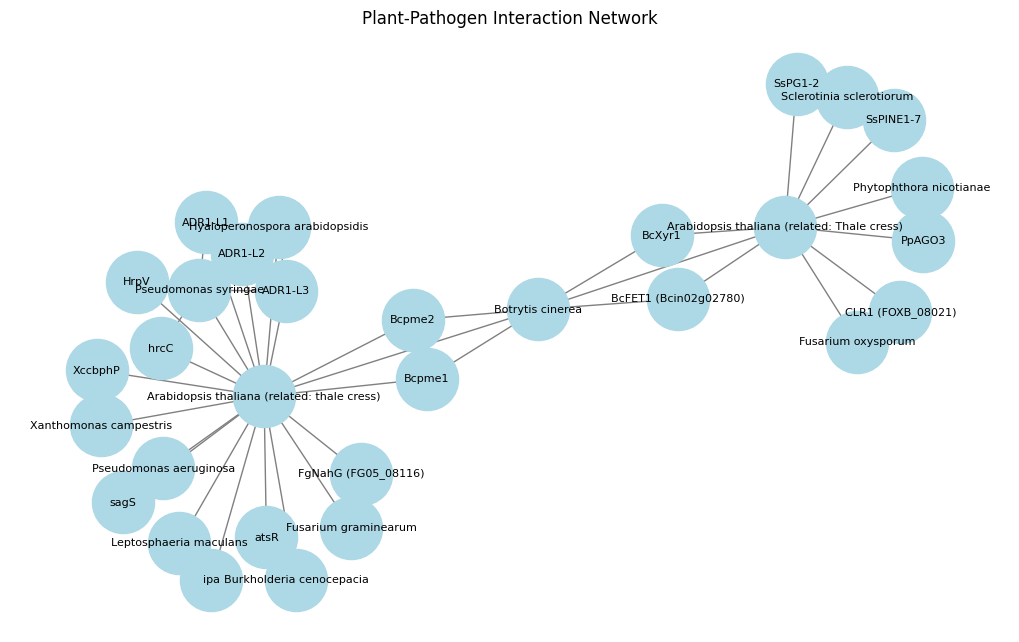

In [5]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Load the cleaned dataset
df = pd.read_csv("cleaned_phi_base.csv")

# Create an empty graph
G = nx.Graph()

# Add edges between Pathogen and Host
for index, row in df.iterrows():
    pathogen = row["Pathogen Species"]
    host = row["Host Species"]
    gene = row["Pathogen Gene"]
    
    # Add nodes
    G.add_node(pathogen, type="pathogen")
    G.add_node(host, type="host")
    G.add_node(gene, type="gene")
    
    # Add edges (relationships)
    G.add_edge(pathogen, host, relation="infects")
    G.add_edge(pathogen, gene, relation="mutates")
    G.add_edge(gene, host, relation="affects")

# Draw the graph
plt.figure(figsize=(10, 6))
pos = nx.spring_layout(G)  # Positioning of nodes
nx.draw(G, pos, with_labels=True, node_color="lightblue", edge_color="gray", node_size=2000, font_size=8)
plt.title("Plant-Pathogen Interaction Network")
plt.show()


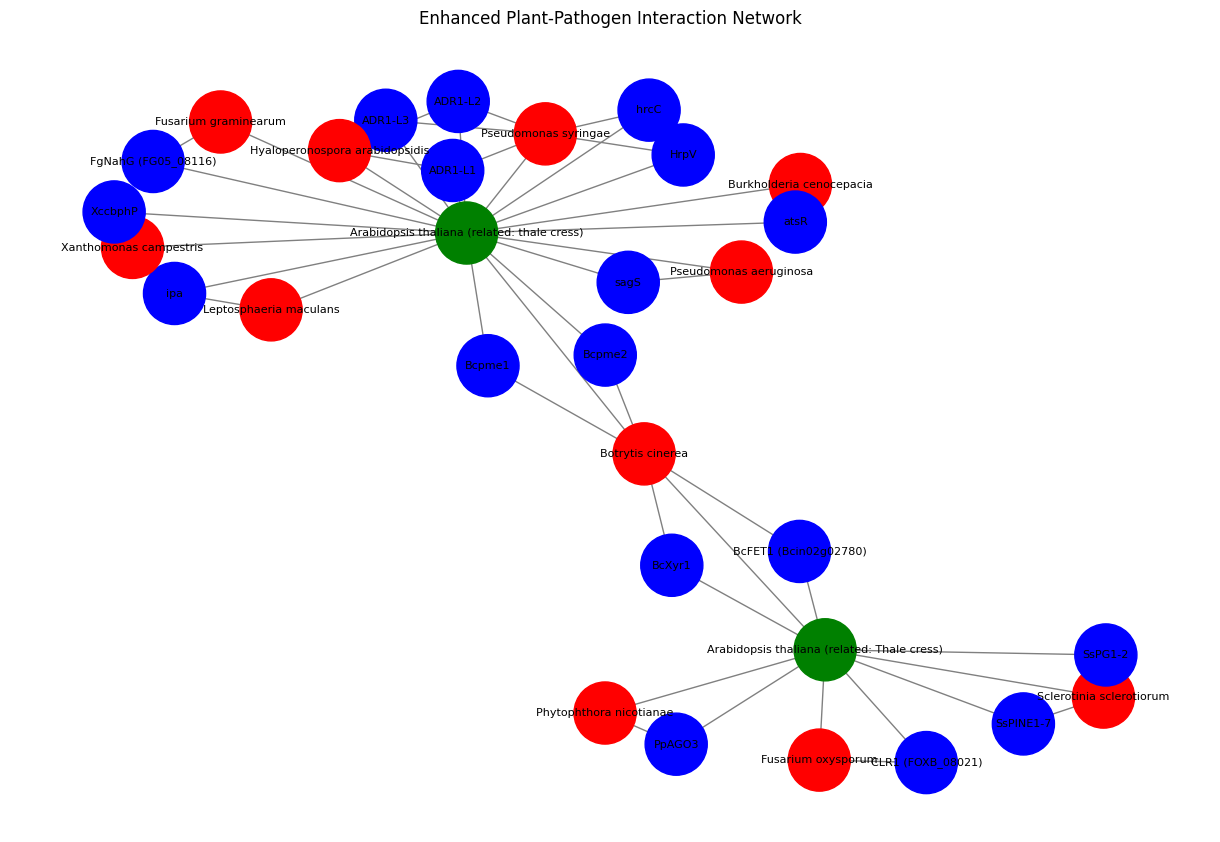

In [6]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Load the cleaned dataset
df = pd.read_csv("cleaned_phi_base.csv")

# Create an empty graph
G = nx.Graph()

# Define colors based on node type
node_colors = {}

# Add edges between Pathogen and Host
for index, row in df.iterrows():
    pathogen = row["Pathogen Species"]
    host = row["Host Species"]
    gene = row["Pathogen Gene"]
    
    # Add nodes with different colors
    G.add_node(pathogen, type="pathogen")
    node_colors[pathogen] = "red"  # Pathogens = Red
    
    G.add_node(host, type="host")
    node_colors[host] = "green"  # Hosts = Green
    
    G.add_node(gene, type="gene")
    node_colors[gene] = "blue"  # Genes = Blue
    
    # Add edges (relationships)
    G.add_edge(pathogen, host, relation="infects")
    G.add_edge(pathogen, gene, relation="mutates")
    G.add_edge(gene, host, relation="affects")

# Draw the graph
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G)  # Positioning of nodes
node_colors_list = [node_colors[node] for node in G.nodes]  # Assign colors

nx.draw(G, pos, with_labels=True, node_color=node_colors_list, edge_color="gray",
        node_size=2000, font_size=8, font_color="black")

plt.title("Enhanced Plant-Pathogen Interaction Network")
plt.show()


In [7]:
# Find the most connected node (highest degree)
degree_centrality = nx.degree_centrality(G)
most_connected = max(degree_centrality, key=degree_centrality.get)

print("🔹 Most connected node:", most_connected)
print("🔹 Degree centrality:", degree_centrality[most_connected])


🔹 Most connected node: Arabidopsis thaliana (related: thale cress)
🔹 Degree centrality: 0.6666666666666666


In [8]:
# Save the NetworkX graph as a GraphML file
nx.write_graphml(G, "plant_pathogen_network.graphml")

print("✅ Graph saved as 'plant_pathogen_network.graphml'")


✅ Graph saved as 'plant_pathogen_network.graphml'


In [9]:
nx.write_graphml(G, "plant_pathogen_network.graphml")
